# Cross integration: Multiple RNA + ADT, every method

This notebook runs every method that has a variant for cross Multiple RNA + ADT on `D52mini`: Concerto, MOFA2, Multigrate, StabMap, UINMF, scMDC, scMM, scMoMaT, sciPENN and totalVI. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/cross_rna_adt/) explains each step and runs StabMap and sciPENN only.

Methods run on Linux. The environments are 9 envs, 25.2 GB to download on a CPU host, 31.0 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D52mini")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["Concerto", "MOFA2", "Multigrate", "StabMap", "UINMF", "scMDC", "scMM",
           "scMoMaT", "sciPENN", "totalVI"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,scmb_r,"[StabMap, UINMF]",have
1,MOFA2_env,[MOFA2],have
2,env_sciPENN,[sciPENN],have
3,scmb_concerto,[Concerto],have
4,scmb_multigrate2,[Multigrate],have
5,scmb_scmdc,[scMDC],have
6,scmb_scmm2,[scMM],have
7,scmb_scvi,[totalVI],have
8,scmb_torch,[scMoMaT],have


## 3. Run the methods

In [4]:
res = mtb.run_all("D52mini", "cross", methods=METHODS,
                  out_dir="out/D52mini_all")
res.summary

[run_all] UINMF runs on rna1+rna2+rna3+adt1+adt2+adt3, not on rna1+rna2+adt1+adt2, whose files are part of it. Pass modalities= to run a smaller combination.


[run_all] 18 more rows need files this folder does not have. mtb.scan shows them.


[run_all] Concerto (cross/D52mini) ...


[run_all]   -> CHAIN_OK (32.8s) ARI 0.595


[run_all] MOFA2 (cross/D52mini) ...


...

[run_all] sciPENN (cross/D52mini) ...


[run_all]   -> CHAIN_OK (9.4s) ARI 0.719


[run_all] totalVI (cross/D52mini) ...


[run_all]   -> CHAIN_OK (71.2s) ARI 0.744


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,...,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,Concerto,CHAIN_OK,32.8,embedding,"[3000, 128]",0,cty1.csv+cty2.csv+cty3.csv,0.8404,file_of_origin,3,...,0.5116,0.5102,0.4014,0.9643,0.9424,0.8344,0.6031,None,,
1,MOFA2,CHAIN_OK,16.0,embedding,"[3000, 20]",0,cty1.csv+cty2.csv+cty3.csv,0.6660,file_of_origin,3,...,0.4786,0.4797,0.4423,0.9447,0.8075,0.8126,0.1750,None,,
2,Multigrate,CHAIN_OK,41.1,embedding,"[3000, 15]",3,cty1.csv+cty2.csv+cty3.csv,0.8718,file_of_origin,3,...,0.5978,0.5714,0.5614,0.9896,0.8563,0.8595,0.7246,None,,
3,StabMap,CHAIN_OK,10.2,embedding,"[3000, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.8717,file_of_origin,3,...,0.5072,0.5188,0.4865,0.9605,0.8511,0.8610,0.6834,None,,
4,UINMF,CHAIN_OK,18.9,embedding,"[3000, 30]",0,cty1.csv+cty2.csv+cty3.csv,0.9002,file_of_origin,3,...,0.5540,0.5378,0.5351,0.9824,0.8540,0.8393,0.7335,None,,
5,scMDC,CHAIN_OK,53.4,embedding,"[3000, 16]",24,cty1.csv+cty2.csv+cty3.csv,0.8804,file_of_origin,3,...,0.6097,0.5835,0.6477,0.9906,0.8155,0.8981,0.6475,None,,
6,scMM,CHAIN_OK,13.0,embedding,"[3000, 10]",19,cty1.csv+cty2.csv+cty3.csv,0.7616,file_of_origin,3,...,0.4797,0.4925,0.2932,0.9447,0.8015,0.7996,0.3855,None,,
7,scMoMaT,CHAIN_OK_GRAPH_METHOD,148.4,graph,"[3000, 2]",0,cty1.csv+cty2.csv+cty3.csv,0.9372,file_of_origin,3,...,0.6130,0.5686,0.6026,0.9902,0.6928,0.7889,0.7579,None,,
8,sciPENN,CHAIN_OK,9.4,embedding,"[3000, 512]",1,cty1.csv+cty2.csv+cty3.csv,0.8443,file_of_origin,3,...,0.6071,0.5940,0.5881,0.9906,0.8338,0.9098,0.6146,None,,
9,totalVI,CHAIN_OK,71.2,embedding,"[3000, 20]",0,cty1.csv+cty2.csv+cty3.csv,0.8560,file_of_origin,3,...,0.5513,0.5772,0.6408,0.9774,0.9195,0.9498,0.7519,None,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

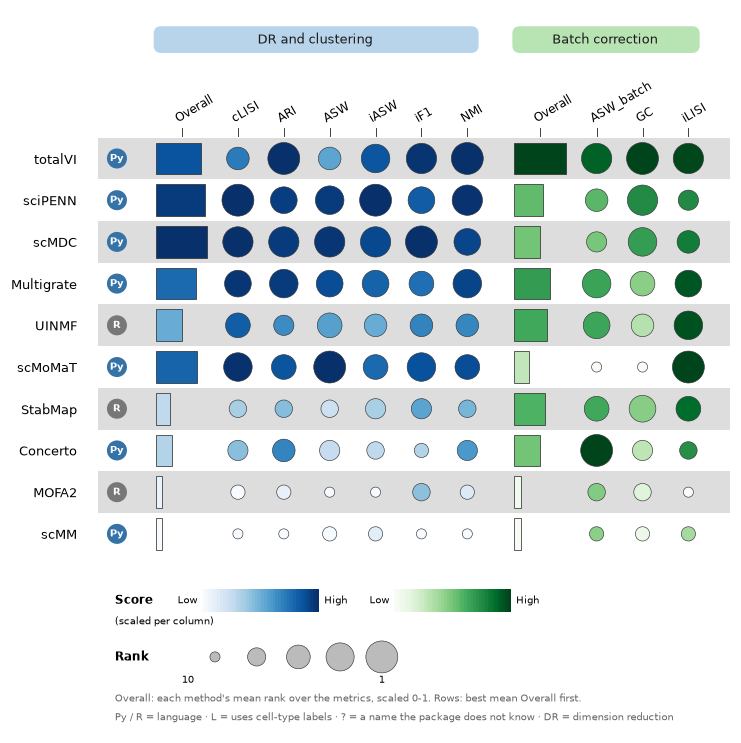

In [5]:
res.plot()